# Transformer Notebook


## Section 1: Why Attention Is Not Enough
Attention allows tokens to communicate.
We still need a mechanism to transform information.
We still need stable training.

## Section 2: Layer Normalization
Implement normalization manually

In [38]:
import torch
import torch.nn as nn


x = torch.tensor([
    [1.0, 2.0, 3.0],
    [5.0, 10.0, 15.0]
])

h_layer = nn.Sequential(nn.Linear(3, 4), nn.GELU(), nn.Linear(4, 3))
out = h_layer(x)

# Calculate - See pages 100 - 104
mean = out.mean(dim=-1, keepdim=True) # Expect something ~0
variance = out.var(dim=-1, keepdim=True) # Expect something ~1
normalized_output = (out - mean) / torch.sqrt(variance + 1e-5)

In [39]:
# Verify with
print(normalized_output.mean(dim=-1))
print(normalized_output.var(dim=-1, unbiased=False))

tensor([-3.9736e-08, -3.9736e-08], grad_fn=<MeanBackward1>)
tensor([0.6666, 0.6667], grad_fn=<VarBackward0>)


## Section 3: Exploring GELU
Compare ReLU and GELU

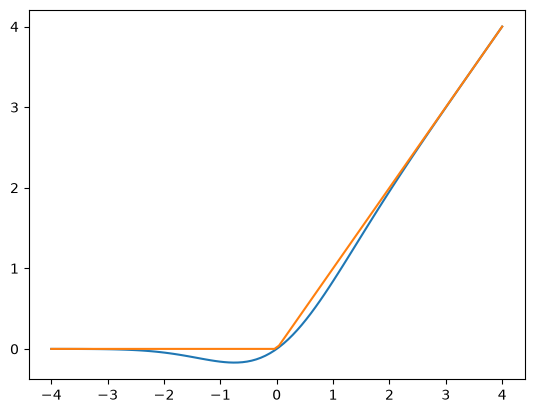

In [40]:
import matplotlib.pyplot as plt

# Use this and plot both
linspace = torch.linspace(-4, 4, 100)

gelu = torch.nn.GELU()
relu = torch.nn.ReLU()

g_out = gelu(linspace)
r_out = relu(linspace)

plt.plot(linspace, g_out)
plt.plot(linspace, r_out)
plt.show()

## Section 4: Feed Forward Network
Review figure 4.10 in the book

In [41]:
# Create
input_shape = (2, 3, 768)

batch = torch.randn(input_shape)

In [42]:
# Pass through 
#  Linear - Expect (2,3,768)
trf1 = nn.Linear(768, 768*4)
x_1 = trf1(batch)
print(x_1.shape)

#  GELU - Expect (2,3,3072)
trf2 = nn.GELU()
x_2 = trf2(x_1)
print(x_2.shape)

#  Linear again - Expect (2,3,768) again
trf3 = nn.Linear(768*4, 768)
x_3 = trf3(x_2)
print(x_3.shape)


torch.Size([2, 3, 3072])
torch.Size([2, 3, 3072])
torch.Size([2, 3, 768])


## Section 5: Residual Connections
Inspect output shapes using a toy network
Compare
 - With residual
 - Without residual

In [46]:
output = x + layer(x)

print(output)

output = layer(x)

print(output)

tensor([[ 0.8578,  1.2275,  3.0082],
        [ 3.5272,  5.5912, 15.4826]], grad_fn=<AddBackward0>)
tensor([[-0.1422, -0.7725,  0.0082],
        [-1.4728, -4.4088,  0.4826]], grad_fn=<AddmmBackward0>)


## Section 6: Connecting Everything
This notebook has walked you through the following process, which is the blueprint for a TransformerBlock
 - Input
 - LayerNorm
 - Attention
 - Add Residual
 - LayerNorm
 - FeedForward
 - Add Residual
 - Output